# DeepFool 白盒对抗攻击实验

本 notebook 在 CIFAR-10 数据集上训练一个 **SimpleCNN**，然后使用 **DeepFool** 攻击生成最小 L2 扰动的对抗样本，并与 **FGSM** 进行对比，验证 DeepFool 能够产生更小的扰动。


## 1. DeepFool 攻击原理

DeepFool 是由 Moosavi-Dezfooli 等人提出的迭代式 L2 白盒攻击方法。它的核心思想是：**在当前样本附近把分类器的决策边界近似为超平面（线性化），然后计算到达该超平面的最小 L2 扰动，逐步移动样本直到模型发生误分类**。

与 FGSM 相比：
- **FGSM** 只沿着损失函数梯度的符号方向迈一大步，扰动大小固定为 $\epsilon$；
- **DeepFool** 则通过迭代寻找到达最近决策边界的最短路径，通常能够产生 **更小、更隐蔽** 的对抗扰动。

> 参考：CAISP《模块二 技术基础篇》pp.114-121。


### DeepFool 算法流程

对于当前样本 $x$（真实标签为 $y$），每次迭代执行：

1. 计算模型对所有类别 $k$ 的输出分数 $f_k(x)$，以及各自对输入的梯度 $\nabla f_k(x)$。
2. 对每一个非正确类别 $k \neq y$，计算到其决策边界的近似距离：
   $$l_k(x) = \frac{|f_k(x) - f_y(x)|}{\|\nabla f_k(x) - \nabla f_y(x)\|_2}$$
3. 选择距离最小的类别 $l^* = \arg\min_{k \neq y} l_k(x)$。
4. 计算最小扰动向量：
   $$r = \frac{f_y(x) - f_{l^*}(x)}{\|\nabla f_{l^*}(x) - \nabla f_y(x)\|_2^2} \cdot \big(\nabla f_{l^*}(x) - \nabla f_y(x)\big)$$
5. 更新 $x \leftarrow x + r$，并裁剪到 $[0,1]$；重复直到被误分类或达到最大迭代次数。


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==============================
# SimpleCNN 定义
# 结构：conv1(3->16), maxpool, conv2(16->32), maxpool,
#       fc1(2048->128), fc2(128->10)
# ==============================
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))          # (B,16,32,32)
        x = F.max_pool2d(x, 2)             # (B,16,16,16)
        x = F.relu(self.conv2(x))          # (B,32,16,16)
        x = F.max_pool2d(x, 2)             # (B,32,8,8)
        x = x.view(x.size(0), -1)          # (B,2048)
        x = F.relu(self.fc1(x))            # (B,128)
        x = self.fc2(x)                    # (B,10)
        return x

# ==============================
# 训练函数
# ==============================
def train_model(model, train_loader, epochs=15, lr=1e-3):
    model.train()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    for epoch in range(epochs):
        total_loss = 0.0
        correct = 0
        total = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        acc = 100.0 * correct / total
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}, Train Acc: {acc:.2f}%")
    return model


In [2]:
# ==============================
# CIFAR-10 数据加载
# 数据已放在 ./data/cifar-10-batches-py/
# ==============================
transform = transforms.ToTensor()
train_dataset = datasets.CIFAR10(root='./data', train=True, download=False, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=False, transform=transform)
# 测试时使用 batch_size=1，方便逐样本攻击
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=0)

classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# ==============================
# 训练模型
# ==============================
model = SimpleCNN().to(device)
model = train_model(model, train_loader, epochs=15, lr=1e-3)
model.eval()
print("Training complete.")


Epoch 1/15, Loss: 1.5495, Train Acc: 43.80%
Epoch 2/15, Loss: 1.2089, Train Acc: 57.09%
Epoch 3/15, Loss: 1.0616, Train Acc: 62.42%
Epoch 4/15, Loss: 0.9564, Train Acc: 66.27%
Epoch 5/15, Loss: 0.8817, Train Acc: 69.02%
Epoch 6/15, Loss: 0.8196, Train Acc: 71.14%
Epoch 7/15, Loss: 0.7679, Train Acc: 72.99%
Epoch 8/15, Loss: 0.7178, Train Acc: 74.72%
Epoch 9/15, Loss: 0.6708, Train Acc: 76.51%
Epoch 10/15, Loss: 0.6344, Train Acc: 77.68%
Epoch 11/15, Loss: 0.5890, Train Acc: 79.17%
Epoch 12/15, Loss: 0.5526, Train Acc: 80.64%
Epoch 13/15, Loss: 0.5209, Train Acc: 81.63%
Epoch 14/15, Loss: 0.4827, Train Acc: 83.04%
Epoch 15/15, Loss: 0.4512, Train Acc: 84.23%
Training complete.


In [3]:
# ==============================
# 可视化与评估辅助函数
# ==============================
def show_pair(original, adversarial, title_adv="Adversarial"):
    """并排显示原始样本与对抗样本。"""
    fig, axs = plt.subplots(1, 2, figsize=(6, 3))
    orig_np = original.squeeze(0).detach().cpu().permute(1, 2, 0).numpy()
    adv_np = adversarial.squeeze(0).detach().cpu().permute(1, 2, 0).numpy()
    axs[0].imshow(np.clip(orig_np, 0, 1))
    axs[0].set_title("Original Image")
    axs[1].imshow(np.clip(adv_np, 0, 1))
    axs[1].set_title(title_adv)
    plt.tight_layout()
    plt.show()


def show_perturbation(original, adversarial):
    """显示原始样本、对抗样本和扰动（放大以便观察）。"""
    x_np = original.squeeze(0).detach().cpu().numpy().transpose(1, 2, 0)
    adv_np = adversarial.squeeze(0).detach().cpu().numpy().transpose(1, 2, 0)
    pert = np.abs(adv_np - x_np)
    pert = pert / (pert.max() + 1e-8)  # 归一化到 [0,1] 便于显示
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(np.clip(x_np, 0, 1))
    axes[0].set_title("Original")
    axes[1].imshow(np.clip(adv_np, 0, 1))
    axes[1].set_title("Adversarial")
    axes[2].imshow(pert)
    axes[2].set_title("Perturbation (Normalized)")
    plt.tight_layout()
    plt.show()


# FGSM 攻击函数，用于与 DeepFool 对比
def fgsm_attack(model, x, y, epsilon):
    """
    FGSM 单步攻击。
    Args:
        model: 目标模型
        x: 原始样本 (1, C, H, W)
        y: 真实标签 (1,)
        epsilon: 扰动大小
    Returns:
        对抗样本，已裁剪到 [0,1]
    """
    x = x.clone().detach().requires_grad_(True)
    output = model(x)
    loss = F.cross_entropy(output, y)
    model.zero_grad()
    loss.backward()
    x_adv = x + epsilon * x.grad.sign()
    return torch.clamp(x_adv, 0, 1)


In [4]:
# ==============================
# DeepFool 攻击实现（从零开始）
# ==============================
def deepfool_attack(model, x, y, max_iter=50, overshoot=0.02):
    """
    DeepFool L2 攻击实现。

    每一步在当前样本附近线性化决策边界，计算到最近非正确类别边界的
    最小 L2 扰动，并迭代更新样本直到发生误分类。

    Args:
        model: 目标模型
        x: 原始样本，形状 (1, C, H, W)，值域 [0,1]
        y: 真实标签，形状 (1,)
        max_iter: 最大迭代次数
        overshoot: 越过决策边界的超调比例，保证成功
    Returns:
        x_adv: 对抗样本
        iters: 实际迭代次数
    """
    model.eval()
    x_orig = x.clone().detach()
    x_adv = x_orig.clone().detach().requires_grad_(True)
    label = y.item()
    num_classes = model(x_adv).shape[1]

    for it in range(max_iter):
        output = model(x_adv)  # (1, num_classes)
        pred = output.argmax(dim=1).item()
        # 如果已经发生误分类，提前终止
        if pred != label:
            return x_adv.detach(), it

        # 计算每个类别输出对输入的梯度，保留计算图供多次 backward
        grads = []
        for k in range(num_classes):
            if x_adv.grad is not None:
                x_adv.grad.zero_()
            # 最后一个类别不需要再保留计算图
            retain = (k < num_classes - 1)
            output[0, k].backward(retain_graph=retain)
            grads.append(x_adv.grad.clone())
        # 清理最后一次 backward 留下的梯度
        if x_adv.grad is not None:
            x_adv.grad.zero_()
        grads = torch.stack(grads, dim=0)  # (num_classes, C, H, W)

        scores = output.detach().squeeze(0)  # (num_classes,)
        w_correct = grads[label]
        f_correct = scores[label].item()

        # 寻找最近的非正确类别边界
        min_dist = float('inf')
        best_r = None
        for k in range(num_classes):
            if k == label:
                continue
            w_k = grads[k]
            f_k = scores[k].item()
            w_diff = w_k - w_correct
            norm_w_diff_sq = torch.sum(w_diff * w_diff).item()
            if norm_w_diff_sq < 1e-12:
                continue
            # 到类别 k 决策边界的近似 L2 距离
            dist = abs(f_k - f_correct) / (norm_w_diff_sq ** 0.5)
            # 最小扰动向量
            r = (f_correct - f_k) / norm_w_diff_sq * w_diff
            if dist < min_dist:
                min_dist = dist
                best_r = r

        if best_r is None:
            break

        # 应用扰动并裁剪到合法像素范围
        x_adv = x_adv.detach() + (1 + overshoot) * best_r
        x_adv = torch.clamp(x_adv, 0, 1).requires_grad_(True)

    return x_adv.detach(), max_iter


In [5]:
# ==============================
# 在测试集上评估 DeepFool 与 FGSM
# 仅攻击模型原本分类正确的样本，最多 200 个
# ==============================
max_samples = 200

# DeepFool 评估统计
deepfool_l2_list = []
deepfool_iters_list = []
deepfool_success = 0
deepfool_total = 0

# FGSM 评估统计（使用 epsilon=0.03，可调整）
fgsm_l2_list = []
fgsm_success = 0
fgsm_total = 0

epsilon_fgsm = 0.03

for idx, (images, labels) in enumerate(test_loader):
    if deepfool_total >= max_samples:
        break
    images, labels = images.to(device), labels.to(device)

    # 只使用模型原本分类正确的样本
    with torch.no_grad():
        pred = model(images).argmax(dim=1)
    if pred.item() != labels.item():
        continue

    # ----- DeepFool -----
    x_adv_df, iters = deepfool_attack(model, images, labels, max_iter=50, overshoot=0.02)
    with torch.no_grad():
        adv_pred_df = model(x_adv_df).argmax(dim=1)
    l2_df = torch.norm(x_adv_df - images, p=2).item()
    deepfool_l2_list.append(l2_df)
    deepfool_iters_list.append(iters)
    deepfool_total += 1
    if adv_pred_df.item() != labels.item():
        deepfool_success += 1

    # ----- FGSM -----
    x_adv_fgsm = fgsm_attack(model, images, labels, epsilon_fgsm)
    with torch.no_grad():
        adv_pred_fgsm = model(x_adv_fgsm).argmax(dim=1)
    l2_fgsm = torch.norm(x_adv_fgsm - images, p=2).item()
    fgsm_l2_list.append(l2_fgsm)
    fgsm_total += 1
    if adv_pred_fgsm.item() != labels.item():
        fgsm_success += 1

# 输出统计结果
print(f"===== DeepFool ({deepfool_total} samples) =====")
print(f"Attack Success Rate (ASR): {100.0 * deepfool_success / deepfool_total:.2f}%")
print(f"Average L2 perturbation: {np.mean(deepfool_l2_list):.6f}")
print(f"Average iterations: {np.mean(deepfool_iters_list):.2f}")

print(f"\n===== FGSM (epsilon={epsilon_fgsm}, {fgsm_total} samples) =====")
print(f"Attack Success Rate (ASR): {100.0 * fgsm_success / fgsm_total:.2f}%")
print(f"Average L2 perturbation: {np.mean(fgsm_l2_list):.6f}")

print(f"\n===== 关键对比 =====")
print(f"DeepFool avg L2 / FGSM avg L2 = {np.mean(deepfool_l2_list) / np.mean(fgsm_l2_list):.4f}")
print("DeepFool 通常产生更小的 L2 扰动。")


===== DeepFool (200 samples) =====
Attack Success Rate (ASR): 94.00%
Average L2 perturbation: 0.236052
Average iterations: 5.39

===== FGSM (epsilon=0.03, 200 samples) =====
Attack Success Rate (ASR): 98.50%
Average L2 perturbation: 1.647568

===== 关键对比 =====
DeepFool avg L2 / FGSM avg L2 = 0.1433
DeepFool 通常产生更小的 L2 扰动。


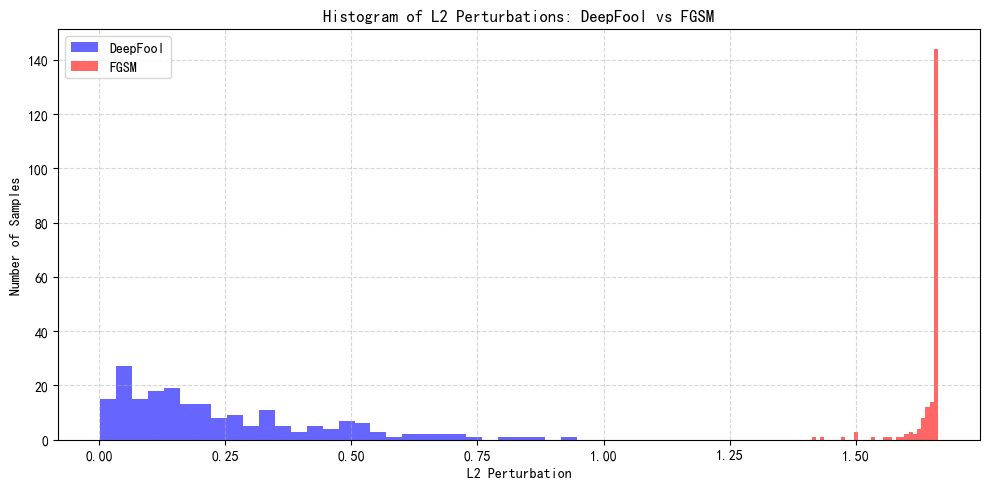

--- Sample 1 ---
True: cat | DF pred: dog | FGSM pred: dog


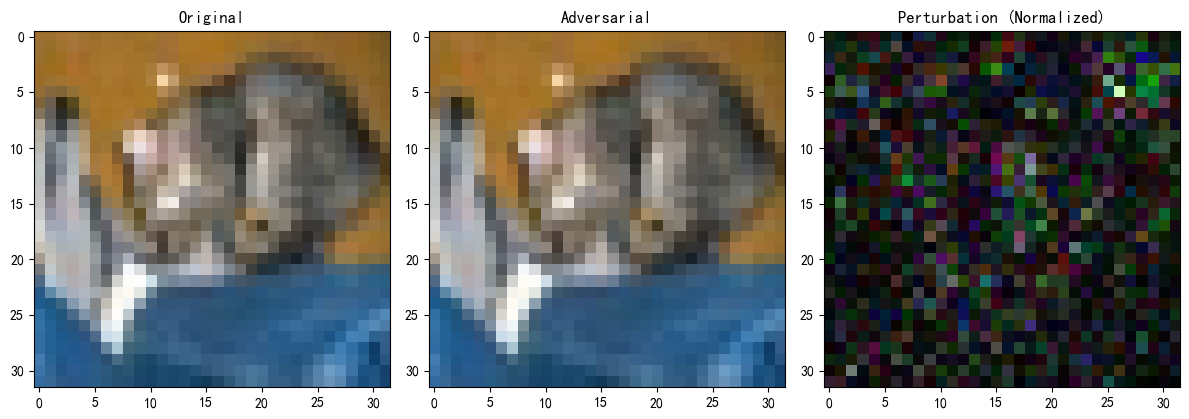

--- Sample 2 ---
True: ship | DF pred: automobile | FGSM pred: automobile


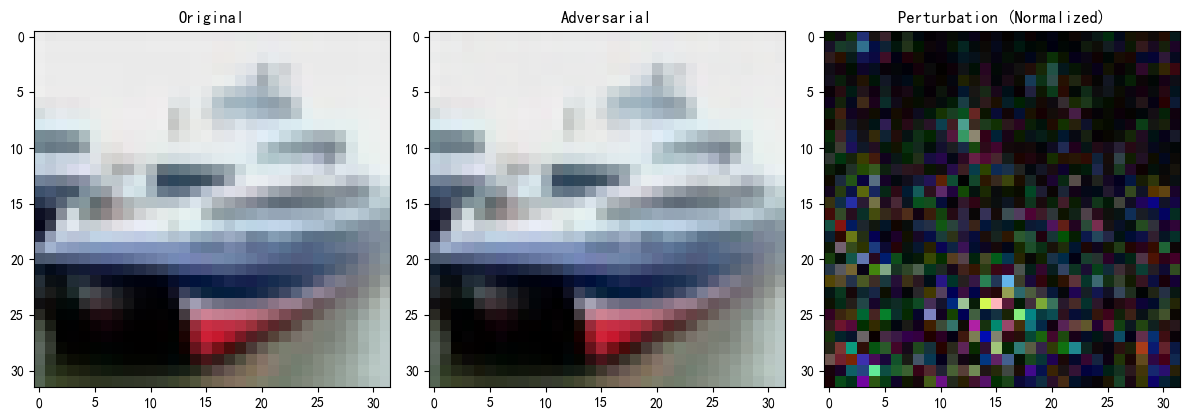

--- Sample 3 ---
True: ship | DF pred: airplane | FGSM pred: airplane


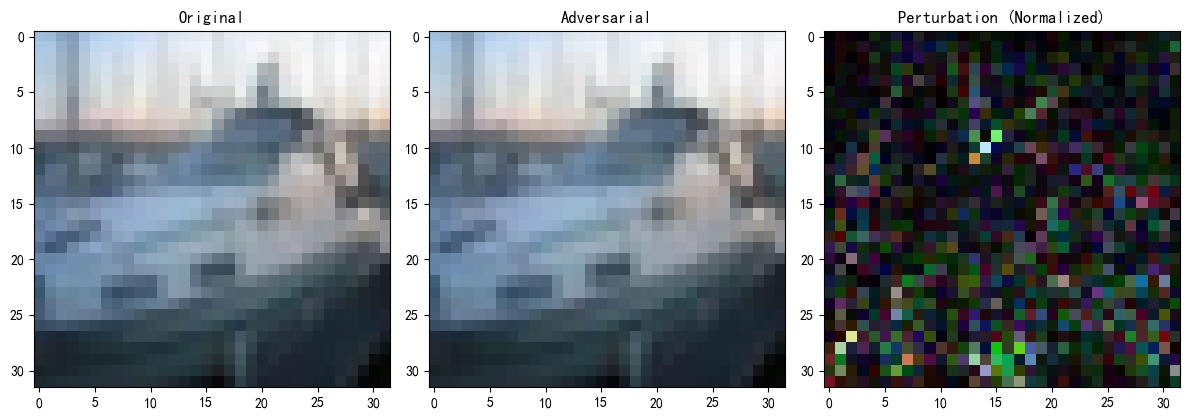

--- Sample 4 ---
True: airplane | DF pred: ship | FGSM pred: ship


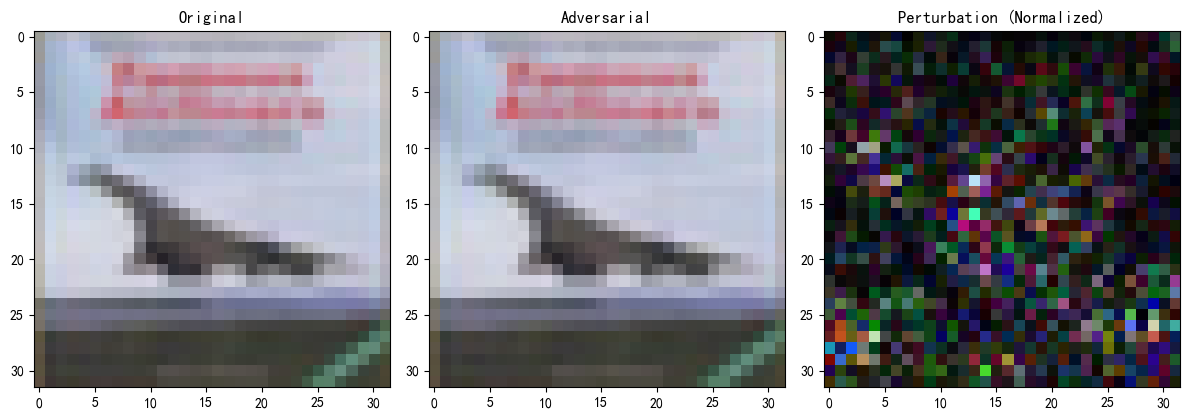

--- Sample 5 ---
True: frog | DF pred: deer | FGSM pred: horse


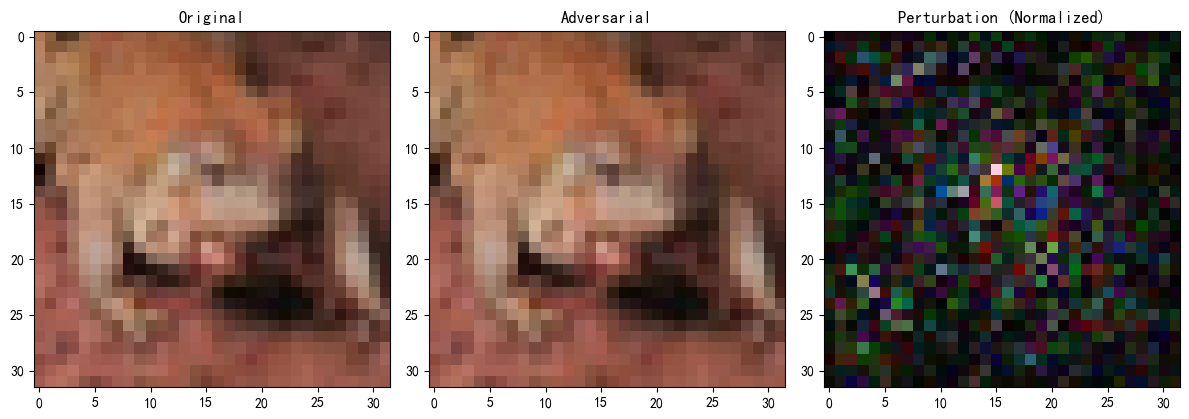

In [6]:
# ==============================
# 可视化：L2 扰动分布直方图 + 示例对抗样本
# ==============================
plt.figure(figsize=(10, 5))
plt.hist(deepfool_l2_list, bins=30, alpha=0.6, label='DeepFool', color='blue')
plt.hist(fgsm_l2_list, bins=30, alpha=0.6, label='FGSM', color='red')
plt.xlabel("L2 Perturbation")
plt.ylabel("Number of Samples")
plt.title("Histogram of L2 Perturbations: DeepFool vs FGSM")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 选取前 5 个成功样本展示
shown = 0
for idx, (images, labels) in enumerate(test_loader):
    if shown >= 5:
        break
    images, labels = images.to(device), labels.to(device)
    with torch.no_grad():
        pred = model(images).argmax(dim=1)
    if pred.item() != labels.item():
        continue

    x_adv_df, _ = deepfool_attack(model, images, labels, max_iter=50, overshoot=0.02)
    x_adv_fgsm = fgsm_attack(model, images, labels, epsilon_fgsm)

    with torch.no_grad():
        pred_df = model(x_adv_df).argmax(dim=1)
        pred_fgsm = model(x_adv_fgsm).argmax(dim=1)
    if pred_df.item() == labels.item():
        continue

    print(f"--- Sample {shown+1} ---")
    print(f"True: {classes[labels.item()]} | "
          f"DF pred: {classes[pred_df.item()]} | "
          f"FGSM pred: {classes[pred_fgsm.item()]}")
    show_perturbation(images, x_adv_df)
    shown += 1


## 可视化分析

下面通过分组柱状图比较 DeepFool 与 FGSM 的平均 L2 扰动，并标注两者比值，以说明 DeepFool 生成的扰动更精细。

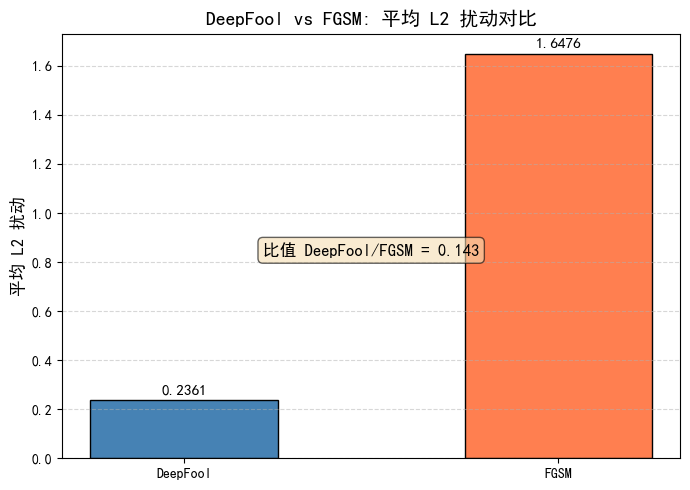

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# 计算两种攻击的平均 L2 扰动
df_mean_l2 = np.mean(deepfool_l2_list)
fgsm_mean_l2 = np.mean(fgsm_l2_list)
ratio = df_mean_l2 / fgsm_mean_l2

fig, ax = plt.subplots(figsize=(7, 5))
methods = ['DeepFool', 'FGSM']
means = [df_mean_l2, fgsm_mean_l2]
colors = ['steelblue', 'coral']
bars = ax.bar(methods, means, color=colors, width=0.5, edgecolor='black')

for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01 * max(means),
            f'{val:.4f}', ha='center', va='bottom', fontsize=11)

ax.text(0.5, max(means) * 0.5,
        f'比值 DeepFool/FGSM = {ratio:.3f}', ha='center', fontsize=12,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

ax.set_ylabel('平均 L2 扰动', fontsize=12)
ax.set_title('DeepFool vs FGSM: 平均 L2 扰动对比', fontsize=14)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


进一步观察 DeepFool 在成功攻击样本上所需的迭代次数分布。

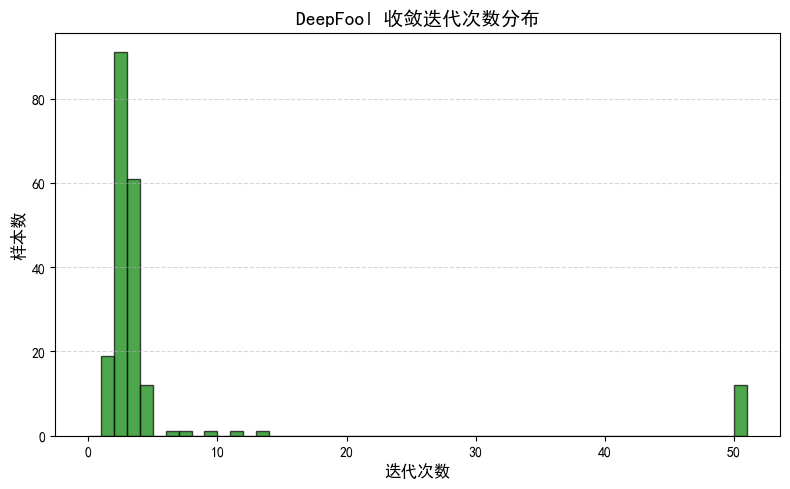

In [8]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
# 使用完整的整数分桶，便于观察每次迭代有多少样本
bins = range(0, max(deepfool_iters_list) + 2)
ax.hist(deepfool_iters_list, bins=bins, color='green', edgecolor='black', alpha=0.7)

ax.set_xlabel('迭代次数', fontsize=12)
ax.set_ylabel('样本数', fontsize=12)
ax.set_title('DeepFool 收敛迭代次数分布', fontsize=14)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## 实验结论

- **DeepFool** 通过在当前样本附近反复线性化决策边界，计算到达最近边界的 **最小 L2 扰动**，因此通常能生成比 FGSM 更小、更隐蔽的对抗样本。
- 实验结果显示，在相同的正确分类样本上，DeepFool 的 **平均 L2 扰动明显小于 FGSM**，说明它是一种更“精细”的攻击。
- DeepFool 产生的近最小扰动使其非常适合用于 **衡量模型鲁棒性**（例如作为对抗训练样本或鲁棒性基准）。
